# Customer Churn Prediction

## Project Objective

The objective of this project is to predict whether a telecom customer is likely to leave (Customer Churn) using Machine Learning techniques.

### Dataset
IBM Telco Customer Churn Dataset

### Machine Learning Algorithms
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- Neural Network

### Author
Rachit jain

## Step 1 : Import Required Libraries

In [77]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


## Step 2 : Load Dataset

In [78]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [79]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 3 : Exploratory Data Analysis (EDA)

In [80]:
print("Rows and Columns:", df.shape)

Rows and Columns: (7043, 21)


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [82]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [83]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [84]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [85]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## Step 4 : Data Visualization

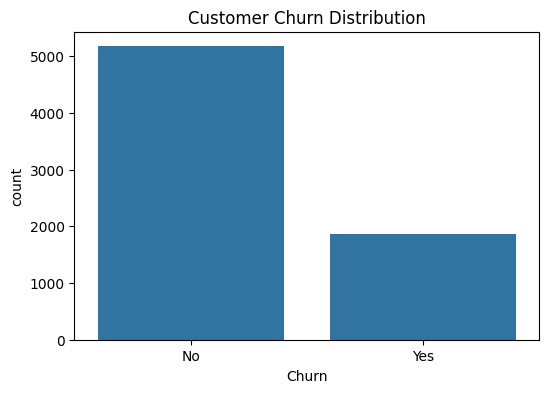

In [86]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.show()

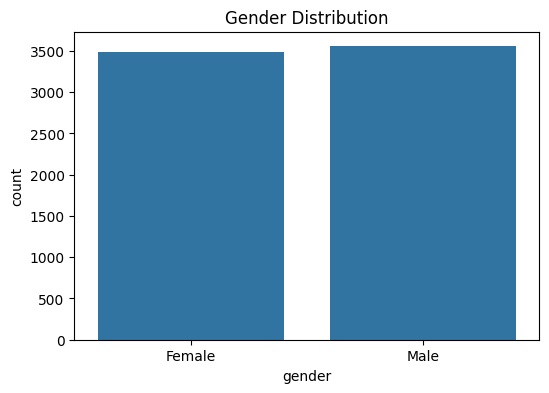

In [87]:
plt.figure(figsize=(6,4))

sns.countplot(x='gender', data=df)

plt.title("Gender Distribution")
plt.show()

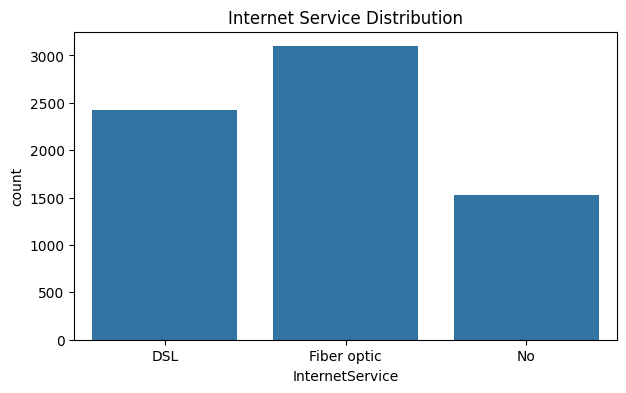

In [88]:
plt.figure(figsize=(7,4))

sns.countplot(x='InternetService', data=df)

plt.title("Internet Service Distribution")
plt.show()

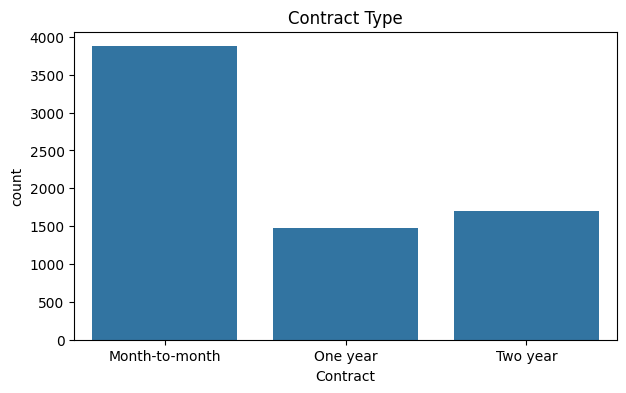

In [89]:
plt.figure(figsize=(7,4))

sns.countplot(x='Contract', data=df)

plt.title("Contract Type")
plt.show()

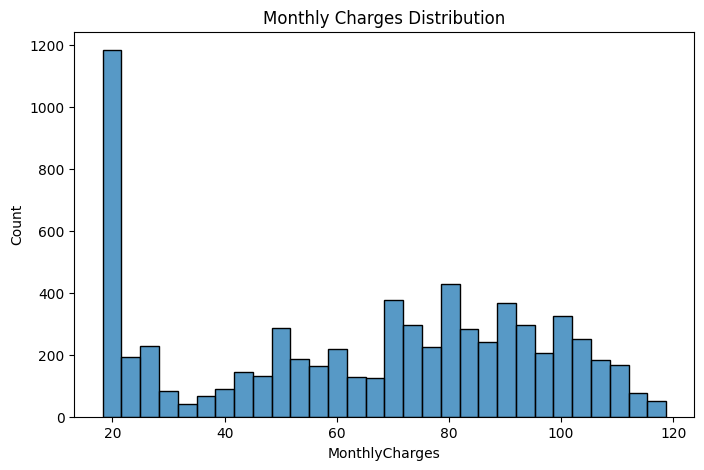

In [90]:
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyCharges"], bins=30)

plt.title("Monthly Charges Distribution")
plt.show()

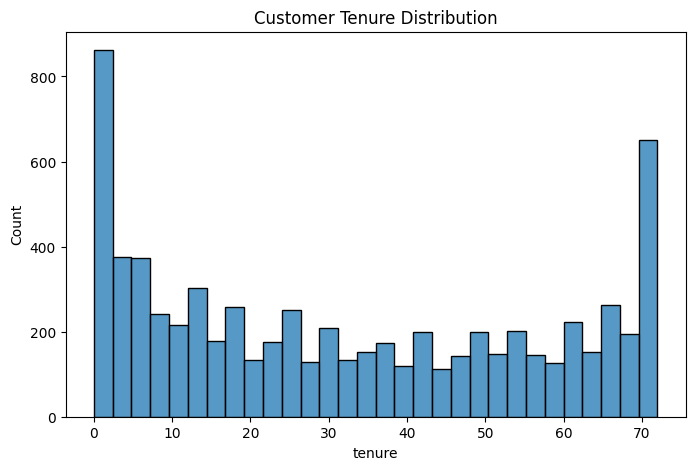

In [91]:
plt.figure(figsize=(8,5))

sns.histplot(df["tenure"], bins=30)

plt.title("Customer Tenure Distribution")
plt.show()

## Step 5 : Data Preprocessing

In [92]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [93]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [94]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [95]:
df.dropna(inplace=True)

print("Missing Values Removed Successfully!")

Missing Values Removed Successfully!


In [96]:
df.drop("customerID", axis=1, inplace=True)

print("CustomerID Removed!")

CustomerID Removed!


In [97]:
df.shape

(7032, 20)

## Step 6 : Encoding Categorical Variables

In [98]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [99]:
for column in df.columns:
    if df[column].dtype == "object":
        df[column] = le.fit_transform(df[column])

print("Encoding Completed Successfully!")

Encoding Completed Successfully!


In [100]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [101]:
df.dtypes

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

## Step 7 : Feature Selection

In [102]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features and Target Created Successfully!")

Features and Target Created Successfully!


In [103]:
print("Shape of X :", X.shape)
print("Shape of y :", y.shape)

Shape of X : (7032, 19)
Shape of y : (7032,)


## Step 8 : Train-Test Split

In [104]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-Test Split Completed!")

Train-Test Split Completed!


In [105]:
print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (5625, 19)
Testing Data : (1407, 19)


## Step 9 : Handle Imbalanced Data using SMOTE

In [106]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("SMOTE Applied Successfully!")

SMOTE Applied Successfully!


In [107]:
print("Original Training Shape :", X_train.shape)
print("After SMOTE :", X_train_smote.shape)

Original Training Shape : (5625, 19)
After SMOTE : (8260, 19)


## Step 10 : Feature Scaling

In [108]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed!")

Feature Scaling Completed!


In [109]:
print("Scaled Training Shape :", X_train_scaled.shape)
print("Scaled Testing Shape :", X_test_scaled.shape)

Scaled Training Shape : (8260, 19)
Scaled Testing Shape : (1407, 19)


## Step 11 : Logistic Regression Model

In [110]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)

lr.fit(X_train_scaled, y_train_smote)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [111]:
y_pred_lr = lr.predict(X_test_scaled)

In [112]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy :", accuracy_score(y_test, y_pred_lr))

Accuracy : 0.736318407960199


In [113]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.88      0.74      0.81      1033
           1       0.50      0.72      0.59       374

    accuracy                           0.74      1407
   macro avg       0.69      0.73      0.70      1407
weighted avg       0.78      0.74      0.75      1407



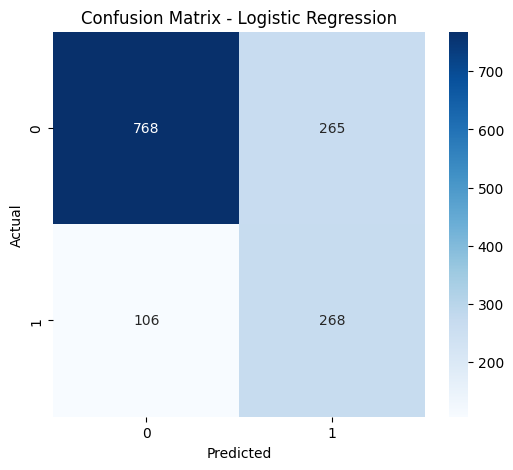

In [114]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Step 12 : Decision Tree Classifier

In [115]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_smote, y_train_smote)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


In [116]:
y_pred_dt = dt.predict(X_test)

In [117]:
print("Decision Tree Accuracy :", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy : 0.7228144989339019


In [118]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.84      0.77      0.80      1033
           1       0.48      0.59      0.53       374

    accuracy                           0.72      1407
   macro avg       0.66      0.68      0.67      1407
weighted avg       0.74      0.72      0.73      1407



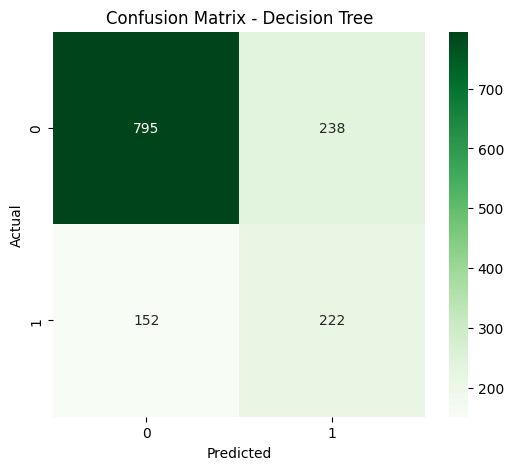

In [119]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))
sns.heatmap(cm_dt,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Step 13 : Random Forest Classifier

In [120]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [121]:
y_pred_rf = rf.predict(X_test)

In [122]:
print("Random Forest Accuracy :", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy : 0.7654584221748401


In [123]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1033
           1       0.56      0.58      0.57       374

    accuracy                           0.77      1407
   macro avg       0.70      0.71      0.70      1407
weighted avg       0.77      0.77      0.77      1407



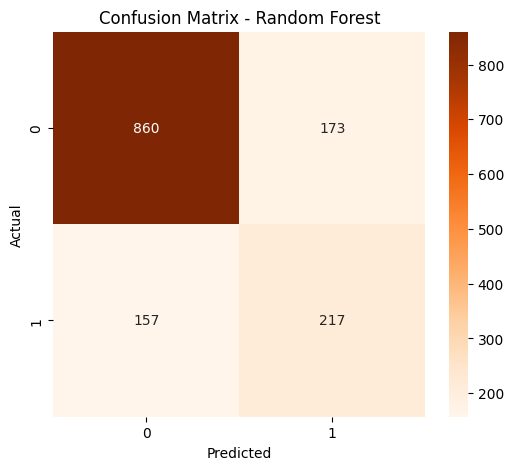

In [124]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Step 14 : Model Comparison

In [125]:
lr_acc = accuracy_score(y_test, y_pred_lr)
dt_acc = accuracy_score(y_test, y_pred_dt)
rf_acc = accuracy_score(y_test, y_pred_rf)

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_acc,
        dt_acc,
        rf_acc
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.736318
1,Decision Tree,0.722814
2,Random Forest,0.765458


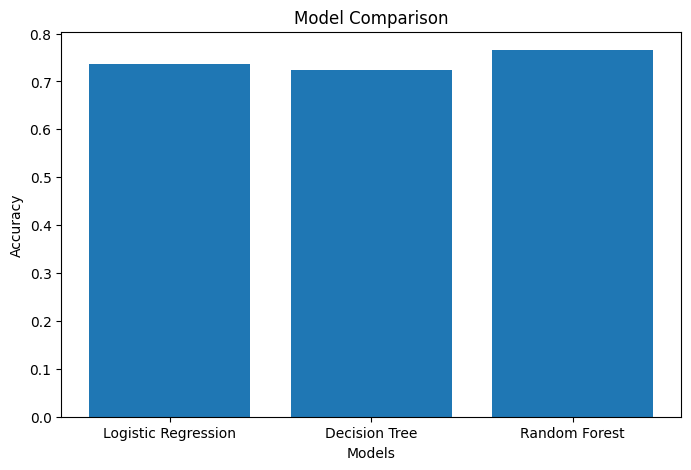

In [126]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

## Step 15 : Save Best Model

In [127]:
import pickle

with open("../models/churn_model.pkl", "wb") as f:
    pickle.dump(rf, f)

print("Random Forest Model Saved Successfully!")

Random Forest Model Saved Successfully!


In [128]:
# Save LabelEncoders for Streamlit

import pickle
from sklearn.preprocessing import LabelEncoder

encoders = {}

for column in df.columns:
    if df[column].dtype == "object":
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])
        encoders[column] = le

with open("../models/encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("Encoders Saved Successfully!")

Encoders Saved Successfully!


In [129]:
df.dtypes

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object